# Credit Card Balance Exploratory Data Analysis

This notebook explores the monthly credit-card records linked to the applicants. It examines the structure of the data, applicant coverage, missing values, account status, balances, credit utilization, payments and overdue behaviour. The findings will be used to guide the cleaning and feature-engineering steps.

## Import libraries


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

# Simple colours used across all EDA notebooks.
BLUE = "#2E6DB4"
ORANGE = "#E67E22"

print("Libraries imported successfully.")


Libraries imported successfully.


## Set file paths


In [5]:
credit_card_path = "data/raw/credit_card_balance.csv"
application_path = "data/raw/application_train.csv"


## Load the data


In [7]:
credit_card = pd.read_csv(credit_card_path)
application_target = pd.read_csv(application_path, usecols=["SK_ID_CURR", "TARGET"])

print("Credit-card rows:", credit_card.shape[0])
print("Credit-card columns:", credit_card.shape[1])
print("Labelled applicants:", len(application_target))
credit_card.head()


Credit-card rows: 3840312
Credit-card columns: 23
Labelled applicants: 307511


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


## Structure, monthly keys, and duplicates


In [9]:
card_month_key = ["SK_ID_PREV", "MONTHS_BALANCE"]

print("Exact duplicate rows:", credit_card.duplicated().sum())
print("Duplicate card-month keys:", credit_card.duplicated(card_month_key).sum())
print("Missing SK_ID_PREV:", credit_card["SK_ID_PREV"].isna().sum())
print("Missing SK_ID_CURR:", credit_card["SK_ID_CURR"].isna().sum())
print("Unique applicants in complete file:", credit_card["SK_ID_CURR"].nunique())
print("Unique previous card accounts:", credit_card["SK_ID_PREV"].nunique())
print("Month range:", credit_card["MONTHS_BALANCE"].min(), "to", credit_card["MONTHS_BALANCE"].max())


Exact duplicate rows: 0
Duplicate card-month keys: 0
Missing SK_ID_PREV: 0
Missing SK_ID_CURR: 0
Unique applicants in complete file: 103558
Unique previous card accounts: 104307
Month range: -96 to -1


## Labelled-applicant coverage

In [11]:
labelled_applicant_ids = set(application_target["SK_ID_CURR"])
card_applicant_ids = set(credit_card["SK_ID_CURR"])

matched_labelled_ids = labelled_applicant_ids.intersection(card_applicant_ids)
labelled_ids_without_cards = labelled_applicant_ids.difference(card_applicant_ids)
card_ids_not_in_application = card_applicant_ids.difference(labelled_applicant_ids)

coverage_percent = len(matched_labelled_ids) / len(labelled_applicant_ids) * 100

print("Labelled applicants with credit-card history:", len(matched_labelled_ids))
print("Applicant coverage:", round(coverage_percent, 2), "%")
print("Labelled applicants without credit-card history:", len(labelled_ids_without_cards))
print("Credit-card applicant IDs not found in application data:", len(card_ids_not_in_application))

Labelled applicants with credit-card history: 86905
Applicant coverage: 28.26 %
Labelled applicants without credit-card history: 220606
Credit-card applicant IDs not found in application data: 16653


In [12]:
coverage_table = application_target.copy()
coverage_table["HAS_CREDIT_CARD_HISTORY"] = coverage_table["SK_ID_CURR"].isin(card_applicant_ids)

coverage_default_summary = coverage_table.groupby("HAS_CREDIT_CARD_HISTORY")["TARGET"].agg(["count", "mean"])
coverage_default_summary["default_rate_percent"] = coverage_default_summary["mean"] * 100
coverage_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
HAS_CREDIT_CARD_HISTORY,,
False,220606,7.84
True,86905,8.67


Only 28.26% of applicants have credit-card history. Applicants with this history have a slightly higher default rate, which could still be a useful signal for the model.


## Missing-value analysis


In [15]:
missing_summary = pd.DataFrame({
    "missing_count": credit_card.isna().sum(),
    "missing_percent": (credit_card.isna().mean() * 100).round(3),
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values("missing_percent", ascending=False)

print("Columns containing missing values:", len(missing_summary))
display(missing_summary)

missing_pattern_columns = [
    "AMT_PAYMENT_CURRENT",
    "AMT_DRAWINGS_ATM_CURRENT",
    "AMT_DRAWINGS_POS_CURRENT",
    "AMT_DRAWINGS_OTHER_CURRENT",
]
missing_pattern_table = credit_card.groupby(credit_card["AMT_CREDIT_LIMIT_ACTUAL"] == 0)[missing_pattern_columns].apply(
    lambda group: group.isna().mean() * 100
)
missing_pattern_table.index = ["Positive credit limit", "Zero credit limit"]
missing_pattern_table.round(2)


Columns containing missing values: 9


,missing_count,missing_percent
AMT_PAYMENT_CURRENT,767988,19.998
AMT_DRAWINGS_ATM_CURRENT,749816,19.525
AMT_DRAWINGS_OTHER_CURRENT,749816,19.525
AMT_DRAWINGS_POS_CURRENT,749816,19.525
CNT_DRAWINGS_ATM_CURRENT,749816,19.525
CNT_DRAWINGS_OTHER_CURRENT,749816,19.525
CNT_DRAWINGS_POS_CURRENT,749816,19.525
AMT_INST_MIN_REGULARITY,305236,7.948
CNT_INSTALMENT_MATURE_CUM,305236,7.948


,AMT_PAYMENT_CURRENT,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT
Positive credit limit,18.76,18.08,18.08,18.08
Zero credit limit,25.08,25.44,25.44,25.44


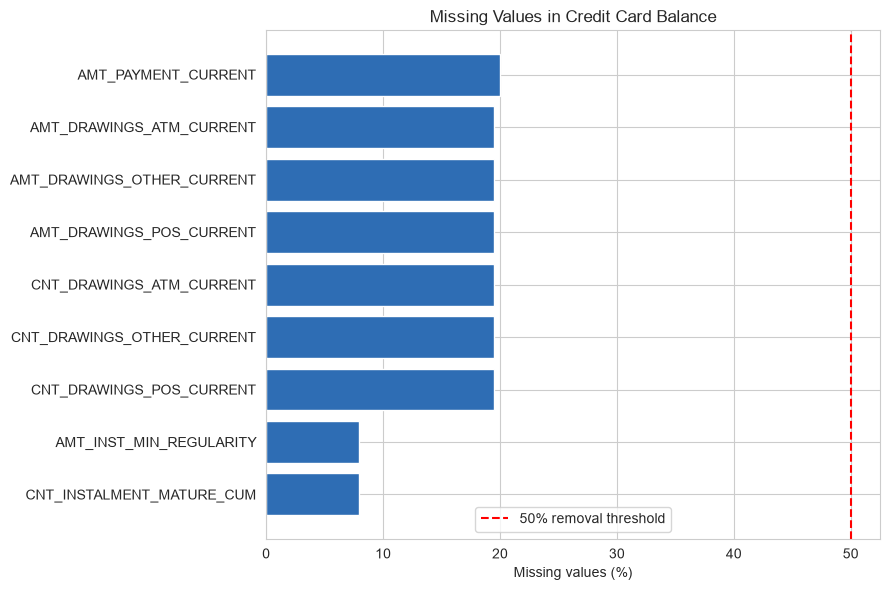

In [16]:
plt.figure(figsize=(9, 6))
plt.barh(missing_summary.index[::-1], missing_summary["missing_percent"][::-1], color=BLUE)
plt.axvline(50, color="red", linestyle="--", label="50% removal threshold")
plt.legend()
plt.title("Missing Values in Credit Card Balance")
plt.xlabel("Missing values (%)")
plt.tight_layout()
plt.show()


None of these columns reach the 50% removal level, so all of them will be kept and handled later during cleaning and modelling.


## Contract status and monthly history


In [19]:
status_table = credit_card["NAME_CONTRACT_STATUS"].value_counts(dropna=False).to_frame("count")
status_table["percent"] = status_table["count"] / len(credit_card) * 100
status_table.round(3)


,count,percent
NAME_CONTRACT_STATUS,,
Active,3698436,96.306
Completed,128918,3.357
Signed,11058,0.288
Demand,1365,0.036
Sent proposal,513,0.013
Refused,17,0.000
Approved,5,0.000


In [20]:
card_history = credit_card.groupby("SK_ID_PREV")["MONTHS_BALANCE"].agg(["count", "min", "max"])
card_history.columns = ["MONTH_COUNT", "OLDEST_MONTH", "MOST_RECENT_MONTH"]
card_history["EXPECTED_MONTH_COUNT"] = card_history["MOST_RECENT_MONTH"] - card_history["OLDEST_MONTH"] + 1
card_history["MISSING_MONTH_COUNT"] = card_history["EXPECTED_MONTH_COUNT"] - card_history["MONTH_COUNT"]

print("Cards with gaps in monthly history:", (card_history["MISSING_MONTH_COUNT"] > 0).sum())
card_history[["MONTH_COUNT", "OLDEST_MONTH", "MOST_RECENT_MONTH", "MISSING_MONTH_COUNT"]].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)


Cards with gaps in monthly history: 14


,MONTH_COUNT,OLDEST_MONTH,MOST_RECENT_MONTH,MISSING_MONTH_COUNT
count,104307.000000,104307.000000,104307.000000,104307.000000
mean,36.817395,-37.336708,-1.518479,0.000834
std,33.362639,33.347442,0.734350,0.086969
min,1.000000,-96.000000,-12.000000,0.000000
25%,10.000000,-75.000000,-2.000000,0.000000
50%,21.000000,-22.000000,-1.000000,0.000000
75%,74.000000,-11.000000,-1.000000,0.000000
90%,95.000000,-7.000000,-1.000000,0.000000
95%,96.000000,-5.000000,-1.000000,0.000000
99%,96.000000,-2.000000,-1.000000,0.000000


Most records belong to active accounts. Very few cards have gaps in their monthly history, so this is not a major issue.


## Numerical and domain checks


In [23]:
important_columns = [
    "AMT_BALANCE",
    "AMT_CREDIT_LIMIT_ACTUAL",
    "AMT_DRAWINGS_CURRENT",
    "AMT_PAYMENT_CURRENT",
    "AMT_PAYMENT_TOTAL_CURRENT",
    "AMT_INST_MIN_REGULARITY",
    "AMT_TOTAL_RECEIVABLE",
    "SK_DPD",
    "SK_DPD_DEF",
]

numeric_summary = credit_card[important_columns].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
numeric_summary[["count", "mean", "min", "1%", "50%", "99%", "max"]]


,count,mean,min,1%,50%,99%,max
AMT_BALANCE,3840312.0,58300.155262,-420250.185,0.00,0.0,466295.11605,1505902.185
AMT_CREDIT_LIMIT_ACTUAL,3840312.0,153807.957400,0.000,0.00,112500.0,765000.00000,1350000.000
AMT_DRAWINGS_CURRENT,3840312.0,7433.388179,-6211.620,0.00,0.0,157500.00000,2287098.315
AMT_PAYMENT_CURRENT,3072324.0,10280.537702,0.000,0.00,2702.7,150617.43000,4289207.445
AMT_PAYMENT_TOTAL_CURRENT,3840312.0,7588.856739,0.000,0.00,0.0,128614.92930,4278315.690
AMT_INST_MIN_REGULARITY,3535076.0,3540.204129,0.000,0.00,0.0,23312.80125,202882.005
AMT_TOTAL_RECEIVABLE,3840312.0,58098.285489,-420250.185,-486.63,0.0,464025.50685,1493338.185
SK_DPD,3840312.0,9.283667,0.000,0.00,0.0,274.00000,3260.000
SK_DPD_DEF,3840312.0,0.331622,0.000,0.00,0.0,1.00000,3260.000


Checking for values that may need attention during cleaning, such as negative balances, zero credit limits, and invalid overdue values. Nothing is removed automatically here, since some of these could be genuine records.


In [25]:
domain_checks = pd.DataFrame({
    "check": [
        "MONTHS_BALANCE is positive",
        "AMT_BALANCE is negative",
        "AMT_CREDIT_LIMIT_ACTUAL is negative",
        "AMT_CREDIT_LIMIT_ACTUAL is zero",
        "AMT_DRAWINGS_CURRENT is negative",
        "AMT_PAYMENT_TOTAL_CURRENT is negative",
        "AMT_TOTAL_RECEIVABLE is negative",
        "SK_DPD is negative",
        "SK_DPD_DEF is negative"
    ],
    "rows_affected": [
        (credit_card["MONTHS_BALANCE"] > 0).sum(),
        (credit_card["AMT_BALANCE"] < 0).sum(),
        (credit_card["AMT_CREDIT_LIMIT_ACTUAL"] < 0).sum(),
        (credit_card["AMT_CREDIT_LIMIT_ACTUAL"] == 0).sum(),
        (credit_card["AMT_DRAWINGS_CURRENT"] < 0).sum(),
        (credit_card["AMT_PAYMENT_TOTAL_CURRENT"] < 0).sum(),
        (credit_card["AMT_TOTAL_RECEIVABLE"] < 0).sum(),
        (credit_card["SK_DPD"] < 0).sum(),
        (credit_card["SK_DPD_DEF"] < 0).sum(),
    ]
})
domain_checks


,check,rows_affected
0,MONTHS_BALANCE is positive,0
1,AMT_BALANCE is negative,2345
2,AMT_CREDIT_LIMIT_ACTUAL is negative,0
3,AMT_CREDIT_LIMIT_ACTUAL is zero,753823
4,AMT_DRAWINGS_CURRENT is negative,3
5,AMT_PAYMENT_TOTAL_CURRENT is negative,0
6,AMT_TOTAL_RECEIVABLE is negative,109330
7,SK_DPD is negative,0
8,SK_DPD_DEF is negative,0


## Create monthly behaviour measures


In [27]:
positive_limit = credit_card["AMT_CREDIT_LIMIT_ACTUAL"] > 0
positive_minimum = credit_card["AMT_INST_MIN_REGULARITY"] > 0

credit_card["UTILIZATION"] = np.nan
credit_card.loc[positive_limit, "UTILIZATION"] = (
    credit_card.loc[positive_limit, "AMT_BALANCE"] / credit_card.loc[positive_limit, "AMT_CREDIT_LIMIT_ACTUAL"]
)
credit_card["PAYMENT_TO_MINIMUM_RATIO"] = np.nan
credit_card.loc[positive_minimum, "PAYMENT_TO_MINIMUM_RATIO"] = (
    credit_card.loc[positive_minimum, "AMT_PAYMENT_TOTAL_CURRENT"]
    / credit_card.loc[positive_minimum, "AMT_INST_MIN_REGULARITY"]
)

credit_card["IS_DELINQUENT"] = (credit_card["SK_DPD_DEF"] > 0).astype(int)
credit_card["IS_SEVERE_DELINQUENCY"] = (credit_card["SK_DPD_DEF"] > 30).astype(int)

credit_card["IS_RECENT_12_MONTHS"] = (credit_card["MONTHS_BALANCE"] >= -12).astype(int)
credit_card["RECENT_DELINQUENCY"] = (
    (credit_card["IS_DELINQUENT"] == 1) & (credit_card["IS_RECENT_12_MONTHS"] == 1)
).astype(int)

credit_card[["UTILIZATION", "PAYMENT_TO_MINIMUM_RATIO"]].describe(
    percentiles=[0.01, 0.50, 0.95, 0.99]
)


,UTILIZATION,PAYMENT_TO_MINIMUM_RATIO
count,3.086489e+06,1.606212e+06
mean,3.746669e-01,8.838681e+00
std,4.307236e-01,2.504665e+03
min,-1.800000e+00,0.000000e+00
1%,0.000000e+00,0.000000e+00
50%,1.134400e-02,1.023672e+00
95%,1.030793e+00,1.241278e+01
99%,1.069404e+00,3.115306e+01
max,1.177751e+01,2.827107e+06


Credit utilization shows how much of the available credit limit has been used. The payment-to-minimum ratio compares the amount paid with the required minimum payment. The delinquency indicators show whether the account was overdue, badly overdue, or overdue in the last 12 months.


## Behaviour distributions


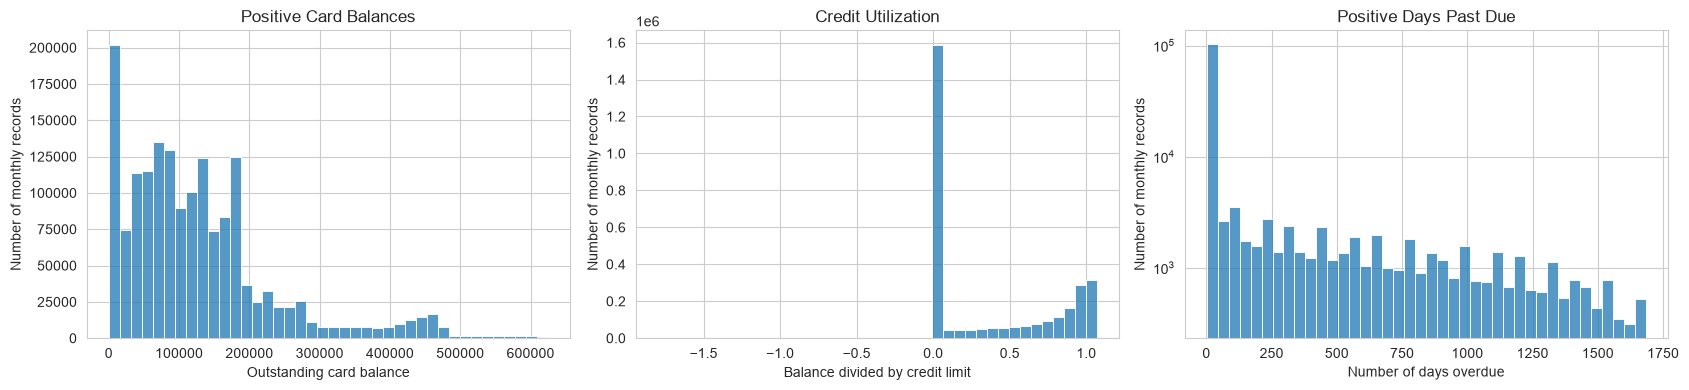

In [30]:
positive_balance = credit_card.loc[credit_card["AMT_BALANCE"] > 0, "AMT_BALANCE"]
positive_dpd = credit_card.loc[credit_card["SK_DPD"] > 0, "SK_DPD"]
valid_utilization = credit_card["UTILIZATION"].dropna()

balance_limit = positive_balance.quantile(0.99)
dpd_limit = positive_dpd.quantile(0.99)
utilization_limit = valid_utilization.quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.histplot(positive_balance[positive_balance <= balance_limit], bins=40, ax=axes[0])
sns.histplot(valid_utilization[valid_utilization <= utilization_limit], bins=40, ax=axes[1])
sns.histplot(positive_dpd[positive_dpd <= dpd_limit], bins=40, ax=axes[2])

axes[0].set_title("Positive Card Balances")
axes[1].set_title("Credit Utilization")
axes[2].set_title("Positive Days Past Due")

axes[0].set_xlabel("Outstanding card balance")
axes[1].set_xlabel("Balance divided by credit limit")
axes[2].set_xlabel("Number of days overdue")

axes[0].set_ylabel("Number of monthly records")
axes[1].set_ylabel("Number of monthly records")
axes[2].set_ylabel("Number of monthly records")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()


Most balances are on the lower end, though a few accounts have much larger ones. Utilization is usually close to zero, but some records are close to or above the credit limit. Most overdue records only have a few overdue days, with a small number showing much longer delays.


## Applicant-level behaviour


In [33]:
credit_card_labelled = credit_card[credit_card["SK_ID_CURR"].isin(labelled_applicant_ids)].copy()

applicant_card = credit_card_labelled.groupby("SK_ID_CURR").agg(
    CC_MONTH_COUNT=("MONTHS_BALANCE", "count"),
    CC_CARD_COUNT=("SK_ID_PREV", "nunique"),
    CC_AVERAGE_BALANCE=("AMT_BALANCE", "mean"),
    CC_MAX_BALANCE=("AMT_BALANCE", "max"),
    CC_AVERAGE_CREDIT_LIMIT=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    CC_MEDIAN_UTILIZATION=("UTILIZATION", "median"),
    CC_MAX_UTILIZATION=("UTILIZATION", "max"),
    CC_AVERAGE_DRAWINGS=("AMT_DRAWINGS_CURRENT", "mean"),
    CC_AVERAGE_PAYMENT=("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
    CC_MEDIAN_PAYMENT_TO_MINIMUM=("PAYMENT_TO_MINIMUM_RATIO", "median"),
    CC_DELINQUENT_MONTH_COUNT=("IS_DELINQUENT", "sum"),
    CC_DELINQUENT_MONTH_RATE=("IS_DELINQUENT", "mean"),
    CC_SEVERE_MONTH_COUNT=("IS_SEVERE_DELINQUENCY", "sum"),
    CC_RECENT_OBSERVED_MONTHS=("IS_RECENT_12_MONTHS", "sum"),
    CC_RECENT_DELINQUENT_COUNT=("RECENT_DELINQUENCY", "sum"),
).reset_index()

applicant_card["CC_RECENT_DELINQUENT_RATE"] = np.where(
    applicant_card["CC_RECENT_OBSERVED_MONTHS"] > 0,
    applicant_card["CC_RECENT_DELINQUENT_COUNT"] / applicant_card["CC_RECENT_OBSERVED_MONTHS"],
    np.nan,
)

print("Labelled applicants with card features:", len(applicant_card))
applicant_card.head()


Labelled applicants with card features: 86905


,SK_ID_CURR,CC_MONTH_COUNT,CC_CARD_COUNT,CC_AVERAGE_BALANCE,CC_MAX_BALANCE,CC_AVERAGE_CREDIT_LIMIT,CC_MEDIAN_UTILIZATION,CC_MAX_UTILIZATION,CC_AVERAGE_DRAWINGS,CC_AVERAGE_PAYMENT,CC_MEDIAN_PAYMENT_TO_MINIMUM,CC_DELINQUENT_MONTH_COUNT,CC_DELINQUENT_MONTH_RATE,CC_SEVERE_MONTH_COUNT,CC_RECENT_OBSERVED_MONTHS,CC_RECENT_DELINQUENT_COUNT,CC_RECENT_DELINQUENT_RATE
0,100006,6,1,0.000000,0.0,270000.000000,0.0,0.00,0.000000,0.000000,NaN,0,0.0,0,6,0,0.0
1,100011,74,1,54482.111149,189000.0,164189.189189,0.0,1.05,2432.432432,4520.067568,1.0,0,0.0,0,11,0,0.0
2,100021,17,1,0.000000,0.0,675000.000000,0.0,0.00,0.000000,0.000000,NaN,0,0.0,0,11,0,0.0
3,100023,8,1,0.000000,0.0,135000.000000,0.0,0.00,0.000000,0.000000,NaN,0,0.0,0,8,0,0.0
4,100036,12,1,0.000000,0.0,78750.000000,0.0,0.00,0.000000,0.000000,NaN,0,0.0,0,11,0,0.0


In [34]:
applicant_card_target = application_target.merge(applicant_card, on="SK_ID_CURR", how="left")
feature_columns = [column for column in applicant_card.columns if column != "SK_ID_CURR"]
feature_correlations = applicant_card_target[feature_columns + ["TARGET"]].corr()["TARGET"].drop("TARGET")
feature_correlations.sort_values().to_frame("correlation_with_target").round(4)


,correlation_with_target
CC_MONTH_COUNT,-0.0605
CC_RECENT_OBSERVED_MONTHS,-0.0190
CC_DELINQUENT_MONTH_COUNT,-0.0103
CC_AVERAGE_CREDIT_LIMIT,-0.0089
CC_MEDIAN_PAYMENT_TO_MINIMUM,-0.0063
CC_DELINQUENT_MONTH_RATE,0.0031
CC_CARD_COUNT,0.0044
CC_SEVERE_MONTH_COUNT,0.0047
CC_AVERAGE_PAYMENT,0.0227
CC_RECENT_DELINQUENT_COUNT,0.0296


In [35]:
delinquent_count = applicant_card_target["CC_DELINQUENT_MONTH_COUNT"]
applicant_card_target["CARD_DELINQUENCY_GROUP"] = np.select(
    [delinquent_count.isna(), delinquent_count > 0],
    ["No credit-card history", "Has delinquent card months"],
    default="No delinquent card months",
)

delinquency_default_summary = applicant_card_target.groupby("CARD_DELINQUENCY_GROUP")["TARGET"].agg(["count", "mean"])
delinquency_default_summary["default_rate_percent"] = delinquency_default_summary["mean"] * 100
delinquency_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
CARD_DELINQUENCY_GROUP,,
Has delinquent card months,14842,7.75
No credit-card history,220606,7.84
No delinquent card months,72063,8.86


A single delinquency grouping does not fully explain default risk on its own. Other measures, like utilization, balances, and recent activity, will likely need to be looked at together.


## Main findings and next step

The credit-card balance table contains monthly records for 103,558 applicants and 104,307 credit-card accounts. The identifiers are complete, and no duplicate account-month records were found.

About 28% of labelled applicants have credit-card history. Nine columns have missing values, but none of them go above the 50% removal level. Most accounts are active, and gaps in monthly history are uncommon.

A few negative balances, negative receivable amounts, zero credit limits, and a small number of negative drawing amounts were found. These will be flagged during cleaning instead of being removed automatically.

Utilization, balances, drawings, and recent payment behaviour all look like they could be useful for default prediction. The next notebook will clean this data and prepare it for feature engineering.
